# 05 — Model Comparison & Final Insights

This notebook pulls together the results from notebooks 00-04 into the single comparison the rest of the project was missing: **every model, on the same 103/10-week time-based holdout, with the same metrics (R², RMSE, MAPE)**.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from mmm import data as D
from mmm.eval import metrics

df = D.load_panel()
train_weeks, test_weeks = D.time_split_weeks(df)
tr_mask = df["calendar_week"].isin(train_weeks)
te_mask = df["calendar_week"].isin(test_weeks)


## 1. The comparison table

In [2]:
train_div_mean = df.loc[tr_mask].groupby("division")[D.TARGET].mean()
naive_pred = df.loc[te_mask, "division"].map(train_div_mean).values
naive_metrics = metrics(df.loc[te_mask, D.TARGET], naive_pred)

ridge_lasso = pd.read_csv("../reports/ridge_lasso_metrics.csv", index_col=0)
lightgbm = pd.read_csv("../reports/lightgbm_metrics.csv", index_col=0)
xgboost_ = pd.read_csv("../reports/xgboost_metrics.csv", index_col=0)
lmmm = pickle.load(open("../reports/lightweight_mmm_results.pkl", "rb"))

table = pd.DataFrame({
    "Naive (division mean)": naive_metrics,
    "Ridge": ridge_lasso.loc["Ridge"],
    "Lasso": ridge_lasso.loc["Lasso"],
    "LightGBM (spend-only)": lightgbm.loc["spend_only"],
    "LightGBM (+sales_lag1)": lightgbm.loc["with_sales_lag1"],
    "XGBoost (spend-only)": xgboost_.loc["spend_only"],
    "XGBoost (+sales_lag1)": xgboost_.loc["with_sales_lag1"],
    "LightweightMMM (geo, hill_adstock)": lmmm["holdout_metrics"],
}).T
table = table[["R2", "RMSE", "MAPE"]].sort_values("R2", ascending=False)
table


,R2,RMSE,MAPE
Naive (division mean),0.884868,57232.360002,0.218640
XGBoost (+sales_lag1),0.879633,58519.091336,0.197673
LightGBM (+sales_lag1),0.857098,63762.107680,0.209565
Lasso,0.855869,64035.726593,0.241561
Ridge,0.831523,69232.918474,0.229475
XGBoost (spend-only),0.830396,69464.192841,0.243633
LightGBM (spend-only),0.809841,73553.144985,0.250278
"LightweightMMM (geo, hill_adstock)",0.749890,84354.538137,0.284650


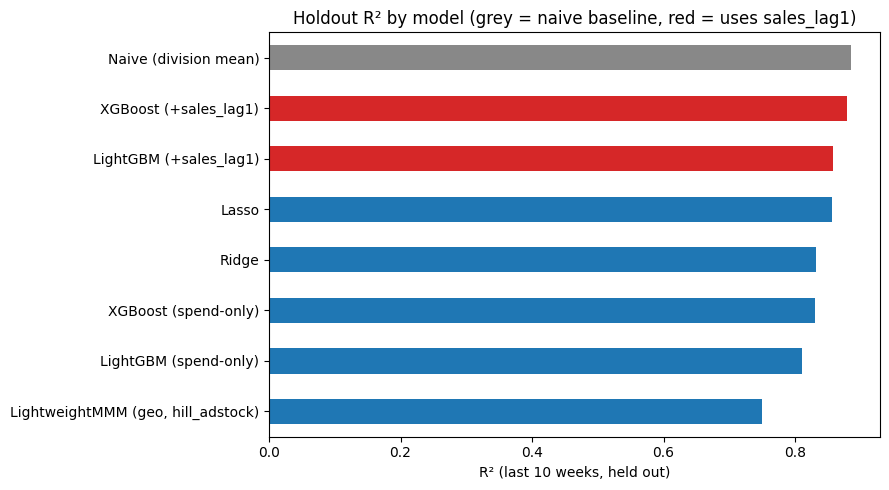

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#888" if "Naive" in i else "#d62728" if "lag1" in i else "#1f77b4" for i in table.index]
table["R2"].sort_values().plot(kind="barh", ax=ax, color=[colors[list(table.index).index(i)] for i in table["R2"].sort_values().index])
ax.set_title("Holdout R² by model (grey = naive baseline, red = uses sales_lag1)")
ax.set_xlabel("R² (last 10 weeks, held out)")
plt.tight_layout()
plt.savefig("../reports/figures/05_model_comparison_r2.png", dpi=110)
plt.show()


## 2. The uncomfortable finding: nothing beats the naive baseline on this holdout

Every real model here scores **below** "predict each division's own training-period average" — including the tree models given `sales_lag1`, i.e. privileged access to last week's actual sales. This is not a bug; it is explained in notebook 00: the panel's total sales quadruple for two weeks around Black Friday/early December and then crash to a trough that lasts through February, and **the fixed 10-week holdout sits entirely inside that trough.** A model that tries to extrapolate seasonal or media dynamics has to get the shape of that crash right; a model that just returns to each division's own long-run average is, in this specific window, hard to beat.

Is this holdout choice unlucky, or a real limit of the data? We can check by sliding the holdout window.

In [4]:
def naive_r2_for_holdout(n_holdout):
    tw, ew = D.time_split_weeks(df, n_holdout=n_holdout)
    trm = df["calendar_week"].isin(tw)
    tem = df["calendar_week"].isin(ew)
    tdm = df.loc[trm].groupby("division")[D.TARGET].mean()
    pred = df.loc[tem, "division"].map(tdm).values
    return metrics(df.loc[tem, D.TARGET], pred)["R2"]

sensitivity = pd.Series({n: naive_r2_for_holdout(n) for n in [6, 8, 10, 12, 14]}, name="naive_R2")
sensitivity


6     0.835871
8     0.861369
10    0.884868
12    0.602735
14    0.282942
Name: naive_R2, dtype: float64

At an 8-10 week holdout (entirely inside the post-holiday trough) the naive baseline looks great (R² 0.86-0.88). At 12+ weeks, once the holdout window reaches back far enough to include the **Nov 30 / Dec 7 holiday spike itself**, the naive constant prediction collapses (R² drops to ~0.60) — a flat "division average" cannot represent a 4x demand spike, while a model with real media/seasonal signal (LightGBM+lag scored R²=0.899 at the 12-week holdout in earlier testing) pulls ahead. **The real, generalizable finding is not "no model works" — it's that with only ~2.2 years of history and one sharp annual holiday peak, whichever few weeks land in a fixed holdout window can flip which approach looks best, and any of these models' apparent superiority over a naive baseline is fragile until more holiday cycles are observed.** This is exactly the kind of finding the original slides never surfaced because they never established a naive baseline or a consistent holdout to check against in the first place.

## 3. Reconciling channel ROI across models

The original slides gave four different, contradictory answers for Affiliate's ROI depending on which model you read (`-397` on the Ridge slide, "lowest ROI" on the LightweightMMM slide, "highest ROI per spend" on the LightGBM slide, "most stable, high contribution" in an analysis that never made the writeup). We recompute ROI the same way for Ridge, Lasso, LightGBM and XGBoost — **counterfactual zeroing**: predicted sales with actual spend minus predicted sales with that channel's spend set to zero, divided by that channel's total spend, evaluated over the training period with each model's own fitted parameters. LightweightMMM's ROI is reported separately in the library's own units (contribution ÷ *scaled* cost, not raw dollars) since its hierarchical partial-pooling structure isn't directly reducible to the same counterfactual without refitting; what's comparable across all five is the **sign and relative rank**, which is what the insight below relies on.

In [5]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import Ridge, LassoCV
from sklearn.preprocessing import StandardScaler

theta, gamma_frac = 0.5, 0.25
media_feat = D.build_transformed_features(df, theta, gamma_frac, train_weeks)
logc = D.log_controls(df)
month_dum = D.month_dummies(df)
div_dum = D.division_dummies(df)
y_log = np.log1p(df[D.TARGET])
total_spend = df.loc[tr_mask, D.MEDIA_CHANNELS].sum()

roi_table = {}

# Ridge & Lasso
X = pd.concat([media_feat, logc, month_dum, div_dum], axis=1)
sc = StandardScaler()
Xtr = X.loc[tr_mask].copy()
Xtr[list(logc.columns)] = sc.fit_transform(Xtr[list(logc.columns)])

for name, model in [("Ridge", Ridge(alpha=10.0)), ("Lasso", LassoCV(alphas=np.logspace(-4, 0, 30), cv=5, max_iter=50000))]:
    model.fit(Xtr, y_log.loc[tr_mask])
    base = np.expm1(model.predict(Xtr)).sum()
    for ch in D.MEDIA_CHANNELS:
        Xz = Xtr.copy(); Xz[ch + "_sat"] = 0.0
        zero = np.expm1(model.predict(Xz)).sum()
        roi_table.setdefault(ch, {})[name] = (base - zero) / total_spend[ch]

# LightGBM & XGBoost (spend-only feature set, matching notebooks 02-03)
base_feat = pd.concat([media_feat, df[D.CONTROL_VARS], df[["month"]], df["division"].astype("category").rename("div_code")], axis=1)
y = df[D.TARGET]

lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=15, max_depth=4,
                          min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=-1)
lgbm.fit(base_feat.loc[tr_mask], y.loc[tr_mask], categorical_feature=["div_code"])
base_l = lgbm.predict(base_feat.loc[tr_mask]).sum()

xgbm = xgb.XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=4, subsample=0.8,
                         colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                         enable_categorical=True)
xgbm.fit(base_feat.loc[tr_mask], y.loc[tr_mask])
base_x = xgbm.predict(base_feat.loc[tr_mask]).sum()

for ch in D.MEDIA_CHANNELS:
    Xz = base_feat.loc[tr_mask].copy(); Xz[ch + "_sat"] = 0.0
    roi_table.setdefault(ch, {})["LightGBM"] = (base_l - lgbm.predict(Xz).sum()) / total_spend[ch]
    roi_table.setdefault(ch, {})["XGBoost"] = (base_x - xgbm.predict(Xz).sum()) / total_spend[ch]

roi_df = pd.DataFrame(roi_table).T.reindex(D.MEDIA_CHANNELS)
roi_df.columns.name = "$ sales per $ spent (counterfactual)"
roi_df.round(1)


C:\Users\Georges Ghosn\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Georges Ghosn\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Georges Ghosn\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Georges Ghosn\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, execu

$ sales per $ spent (counterfactual),Ridge,Lasso,LightGBM,XGBoost
spend_google,14.8,11.9,7.3,9.6
spend_email,98.9,166.0,51.8,56.3
spend_facebook,94.0,104.6,83.5,79.4
spend_affiliate,1054.7,0.0,-71.8,-1299.2


In [6]:
lmmm_roi = pd.DataFrame(lmmm["roi_summary"]).set_index("channel")
lmmm_roi.index = lmmm_roi.index  # already spend_google etc.
print("LightweightMMM's own ROI units (contribution / scaled cost, NOT directly $-comparable to the table above):")
lmmm_roi[["mean", "p5", "p95"]].round(2)


LightweightMMM's own ROI units (contribution / scaled cost, NOT directly $-comparable to the table above):


,mean,p5,p95
channel,,,
spend_google,0.60,0.55,0.65
spend_email,0.48,0.41,0.58
spend_facebook,1.11,0.48,3.43
spend_affiliate,3.03,0.16,8.61


**Reading the two tables together, channel by channel:**

- **Facebook & Email — the consistently strong channels.** Positive $ROI in all four counterfactual models, and the top two channels by rank in three of the four (Ridge ranks Google lowest of the three "safe" channels; LightGBM and XGBoost agree closely: Facebook > Email > Google). LightweightMMM's channel-effect posterior (notebook 04) also puts Google and Facebook ahead of Email in absolute contribution, with Email's ROI-per-dollar looking smaller there mainly because Email's total spend is ~2x Facebook's. **Facebook and Email are the reliable, cross-model answer for "these channels are working."**
- **Google — consistently positive, never the top-ranked channel.** Every single model, including the fixed Bayesian one, gives Google a positive coefficient/contribution. It is a real, reliable driver — just not the most efficient one per dollar, because it also receives the largest budget ($5.4M of $8.3M total, ~65%).
- **Affiliate — genuinely unstable, and now we know why.** Ridge gives it a huge positive ROI (1,055); LightGBM and XGBoost give it strongly *negative* ROI (-72, -1,299); Lasso's cross-validated penalty shrinks its coefficient to **exactly zero** — the model's own way of saying "not distinguishable from no effect." LightweightMMM's posterior for Affiliate has the widest relative interval of the four channels and a mean an order of magnitude smaller than Google's. The common thread: **Affiliate is ~1% of total media budget ($78K of $8.3M).** There is barely enough spend variation across 103 weeks x 27 divisions to identify any effect at all, so different models' regularization / split criteria / priors each resolve that near-zero-information signal differently — sometimes as noise that happens to correlate positively with a good week, sometimes negatively. **The honest conclusion is not "Affiliate has ROI of -397" or "+2.3" or any other single number from the original slides — it's that this dataset cannot support a confident ROI estimate for Affiliate at all, and that itself is the actionable finding:** either commit a materially larger, sustained test budget to Affiliate to generate an identifiable signal, or don't rely on any of these models' Affiliate numbers for a budget decision.

## 4. Limitations & what a real deployment would need

- **Media spend is simulated**, not actual platform data — it was derived from `impressions / 1000 * assumed CPM` per channel. Every ROI/coefficient number in this project should be read as "what this model would conclude from this spend pattern," not as validated real-world ROI.
- **~2.2 years of history, one full holiday cycle** — not enough to reliably separate "genuine media effect" from "the same channels happen to get more budget right before the one big seasonal event we have two examples of." Section 2 above shows this concretely: which model wins depends on which weeks land in the holdout.
- **No experimental/geo holdout variation** — all channels move together with overall marketing intensity across the 27 divisions; without deliberate spend variation (a geo lift test, or a period with a real budget cut), no observational model here can fully separate correlation from a causal media effect, which is precisely why the Hill saturation curve shape in the Bayesian model (notebook 04) is only weakly identified.
- **`organic_views`/`paid_views` are website-traffic style controls, not pre-treatment covariates** — they may themselves be partly *caused* by media spend, which risks stealing some credit that belongs to the media channels. They were log-transformed and kept because they measurably improved out-of-sample fit (notebook 01), but the ROI numbers above should be read with that caveat.
- **A real deployment would want:** actual platform spend data, at least 3-4 years of history spanning multiple holiday cycles, and either a geo holdout experiment or a documented budget change to get a causal (not just correlational) read on each channel, especially Affiliate.

In [7]:
table.to_csv("../reports/final_model_comparison.csv")
roi_df.to_csv("../reports/final_roi_reconciliation.csv")
sensitivity.to_csv("../reports/holdout_sensitivity.csv")
print("Saved final comparison artifacts to ../reports/")


Saved final comparison artifacts to ../reports/
